In [288]:
import tf_keras as keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub

In [289]:
df = pd.read_csv('wine-reviews.csv' , usecols=['country' , 'description' , 'points' , 'price' , 'variety' , 'winery'])
# df = pd.read_csv('wine-reviews.csv')

In [290]:
# head func shows the first 5 rows.
df.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


In [291]:
df.columns[:]

Index(['country', 'description', 'points', 'price', 'variety', 'winery'], dtype='str')

In [292]:
df.dropna(subset=["description" , "points"])

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,90,28.0,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,90,75.0,Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,90,30.0,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",90,32.0,Pinot Gris,Domaine Marcel Deiss


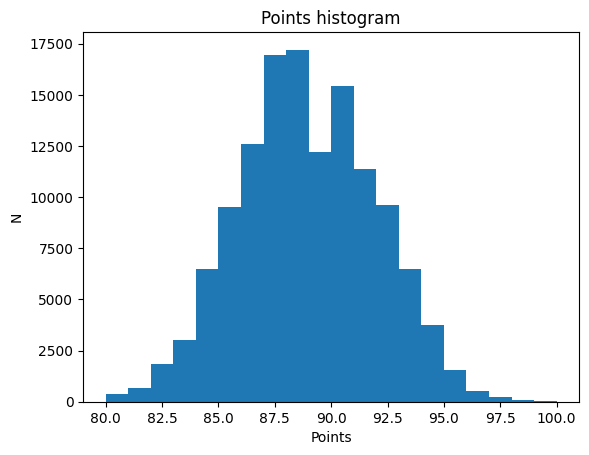

In [293]:
plt.hist(df.points , bins=20)
plt.title("Points histogram")
plt.ylabel("N")
plt.xlabel("Points")
plt.show()

In [294]:
df["label"] = (df.points >= 90).astype(int)
df = df[["description" , "label"]]

In [295]:
df.head()

,description,label
0,"Aromas include tropical fruit, broom, brimston...",0
1,"This is ripe and fruity, a wine that is smooth...",0
2,"Tart and snappy, the flavors of lime flesh and...",0
3,"Pineapple rind, lemon pith and orange blossom ...",0
4,"Much like the regular bottling from 2012, this...",0


In [296]:
# this work in colab due to the version of numpy and pandas

#First shuffle the data , then split the data from 0 to 80% for training , from 80% to 90% for validation and from 90% to 100% for test 
# train, val, test = np.split(df.sample(frac=1), [int(0.8 * len(df)), int(0.9 * len(df))])

# train, val, test = np.split(df.sample(frac=1), [int(0.8*len(df)), int(0.9*len(df))])

# shuffled_df = df.sample(frac=1 , random_state=42)

# train_end = int(0.8 * len(df))
# val_end = int(0.9 * len(df))

# train, val, test = np.split(
#     shuffled_df,
#     [train_end, val_end]
# )

shuffled_df = df.sample(frac=1, random_state=42)

train_end = int(0.8 * len(df))
val_end = int(0.9 * len(df))

train = shuffled_df[:train_end]
val = shuffled_df[train_end:val_end]
test = shuffled_df[val_end:]

In [297]:
len(train) , len(val) , len(test)

(103976, 12997, 12998)

In [298]:
type(train)

pandas.DataFrame

In [299]:
# def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
#   df = dataframe.copy()
#   labels = df.pop('label')
#   df = df["description"]
#   ds = tf.data.Dataset.from_tensor_slices((df, labels))
#   if shuffle:
#     ds = ds.shuffle(buffer_size=len(dataframe))
#   ds = ds.batch(batch_size)
#   ds = ds.prefetch(tf.data.AUTOTUNE)
#   return ds

def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('label')
  df = df["description"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

In [300]:
train_data = df_to_dataset(train)
valid_data = df_to_dataset(val)
test_data = df_to_dataset(test)

In [301]:
embedding = "https://www.kaggle.com/models/google/nnlm/TensorFlow2/en-dim50/1"
hub_layer = hub.KerasLayer(embbeding , dtype=tf.string , trainable=True)

In [302]:
hub_layer(list(train_data)[0][0])

<tf.Tensor: shape=(1024, 50), dtype=float32, numpy=
array([[ 0.17101237, -0.05285905, -0.20860203, ..., -0.05506643,
        -0.14253633,  0.13712397],
       [ 0.6363419 , -0.2851669 , -0.11992304, ..., -0.02084976,
        -0.31968185,  0.10386569],
       [ 0.21775372, -0.24063218,  0.01289806, ..., -0.30788702,
        -0.08626129, -0.15885268],
       ...,
       [ 0.7264811 , -0.14027822,  0.29649138, ...,  0.03540795,
        -0.18536444,  0.03255072],
       [ 0.39483988, -0.2643881 ,  0.00866903, ...,  0.09723967,
        -0.09256802, -0.00750856],
       [ 0.16616371, -0.2349761 ,  0.03711689, ...,  0.06509773,
        -0.16633235, -0.3790881 ]], shape=(1024, 50), dtype=float32)>

In [303]:
model = keras.Sequential([
    hub_layer,
    keras.layers.Dense(16 , activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(16 , activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1 , activation='sigmoid')
])

In [304]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss = keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy']
)

In [305]:
model.evaluate(train_data)

102/102 [==============================] - 1s 5ms/step - loss: 0.7188 - accuracy: 0.3836


[0.7187591195106506, 0.38363659381866455]

In [306]:
model.evaluate(valid_data)

13/13 [==============================] - 0s 5ms/step - loss: 0.7200 - accuracy: 0.3822


[0.7200480699539185, 0.3822420537471771]

In [307]:
history = model.fit(train_data , epochs=10 , validation_data=valid_data)

Epoch 1/10
102/102 [==============================] - 34s 327ms/step - loss: 0.6560 - accuracy: 0.6026 - val_loss: 0.5505 - val_accuracy: 0.7498
Epoch 2/10
102/102 [==============================] - 33s 326ms/step - loss: 0.5118 - accuracy: 0.7535 - val_loss: 0.4156 - val_accuracy: 0.8105
Epoch 3/10
102/102 [==============================] - 33s 326ms/step - loss: 0.4303 - accuracy: 0.7992 - val_loss: 0.3895 - val_accuracy: 0.8208
Epoch 4/10
102/102 [==============================] - 34s 332ms/step - loss: 0.3914 - accuracy: 0.8255 - val_loss: 0.3785 - val_accuracy: 0.8254
Epoch 5/10
102/102 [==============================] - 34s 332ms/step - loss: 0.3629 - accuracy: 0.8428 - val_loss: 0.3782 - val_accuracy: 0.8277
Epoch 6/10
102/102 [==============================] - 33s 326ms/step - loss: 0.3428 - accuracy: 0.8532 - val_loss: 0.3775 - val_accuracy: 0.8278
Epoch 7/10
102/102 [==============================] - 33s 326ms/step - loss: 0.3226 - accuracy: 0.8620 - val_loss: 0.3861 - val_ac

In [310]:
model.evaluate(test_data)

13/13 [==============================] - 0s 19ms/step - loss: 0.4364 - accuracy: 0.8236


[0.4363822638988495, 0.8235882520675659]